<a href="https://colab.research.google.com/github/SebastianSoto17/Computational-Intelligence/blob/main/Redes_convolucionales_con_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Redes Convolucionales con PyTorch


Cargar los datos de CIFAR-10

In [1]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

DATA_ROOT = "./data"

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.4914, 0.4822, 0.4465),
            std=(0.2470, 0.2435, 0.2616),
        ),
    ]
)

train_dataset = datasets.CIFAR10(
    root=DATA_ROOT, train=True, download=True, transform=transform
)
test_dataset = datasets.CIFAR10(
    root=DATA_ROOT, train=False, download=True, transform=transform
)

BATCH_SIZE = 128
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

classes = train_dataset.classes
NUM_CLASSES = len(classes)
IMG_CHANNELS = 3

print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")
print(f"Clases ({NUM_CLASSES}): {classes}")

Dispositivo: cuda


100%|██████████| 170M/170M [00:07<00:00, 24.3MB/s]


Train: 50000 | Test: 10000
Clases (10): ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


CNNs para clasificacion multiclase

In [2]:
model_A = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 32, 3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),
    nn.Conv2d(32, 64, 3, stride=1, padding=1),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.MaxPool2d(2, stride=2),
    nn.Flatten(),
    nn.Linear(64 * 8 * 8, 512),
    nn.Dropout(0.3),
    nn.ReLU(),
    nn.Linear(512, NUM_CLASSES),
).to(device)


model_B = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),
    nn.Conv2d(25, 50, 3, stride=1, padding=1),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.MaxPool2d(2, stride=2),
    nn.Conv2d(50, 75, 3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),
    nn.Flatten(),
    nn.Linear(75 * 4 * 4, 512),
    nn.Dropout(0.3),
    nn.ReLU(),
    nn.Linear(512, NUM_CLASSES),
).to(device)

model_C = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 25, 5, stride=1, padding=2),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),
    nn.Conv2d(25, 50, 3, stride=1, padding=1),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.MaxPool2d(2, stride=2),
    nn.Conv2d(50, 75, 3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),
    nn.Flatten(),
    nn.Linear(75 * 4 * 4, 512),
    nn.Dropout(0.3),
    nn.ReLU(),
    nn.Linear(512, NUM_CLASSES),
).to(device)

named_models = {
    "A (2 conv)": model_A,
    "B (3 conv, 3×3)": model_B,
    "C (3 conv, 5×5 + 3×3)": model_C,
}

for name, m in named_models.items():
    n = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"{name}: {n:,} parametros")

A (2 conv): 2,122,186 parametros
B (3 conv, 3×3): 665,867 parametros
C (3 conv, 5×5 + 3×3): 667,067 parametros


Loop de entrenamiento con tres redes distintas, los hiperparámetros se mantienen igual, al final se evalúa el mejor modelo

Se utiliza Adam como optimizador y la función de pérdida usada es Cross Entropy Loss

Al final se evalúa el mejor modelo

In [3]:
def get_batch_accuracy(output, y, batch_size):
    pred = output.argmax(dim=1, keepdim=True)
    return pred.eq(y.view_as(pred)).sum().item() / batch_size


def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs, device):
    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    iterator = tqdm(range(num_epochs), desc="Entrenando", unit="época")

    for _ in iterator:
        model.train()
        train_loss, train_correct = 0.0, 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            bs = X.size(0)
            train_loss += loss.item() * bs
            train_correct += get_batch_accuracy(out, y, bs) * bs

        epoch_train_loss = train_loss / len(train_loader.dataset)
        epoch_train_acc = train_correct / len(train_loader.dataset)

        model.eval()
        test_loss, test_correct = 0.0, 0
        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                out = model(X)
                bs = X.size(0)
                test_loss += criterion(out, y).item() * bs
                test_correct += get_batch_accuracy(out, y, bs) * bs

        epoch_test_loss = test_loss / len(test_loader.dataset)
        epoch_test_acc = test_correct / len(test_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{epoch_train_acc:.4f}",
            test_loss=f"{epoch_test_loss:.4f}",
            test_acc=f"{epoch_test_acc:.4f}",
        )
        history["train_loss"].append(epoch_train_loss)
        history["train_acc"].append(epoch_train_acc)
        history["test_loss"].append(epoch_test_loss)
        history["test_acc"].append(epoch_test_acc)

    return history


  A (2 conv)


Entrenando: 100%|██████████| 10/10 [02:47<00:00, 16.70s/época, test_acc=0.7475, test_loss=0.7989, train_acc=0.8952, train_loss=0.2951]



  B (3 conv, 3×3)


Entrenando: 100%|██████████| 10/10 [03:02<00:00, 18.21s/época, test_acc=0.7623, test_loss=0.7050, train_acc=0.8525, train_loss=0.4179]



  C (3 conv, 5×5 + 3×3)


Entrenando: 100%|██████████| 10/10 [03:06<00:00, 18.64s/época, test_acc=0.7678, test_loss=0.7044, train_acc=0.8581, train_loss=0.3998]


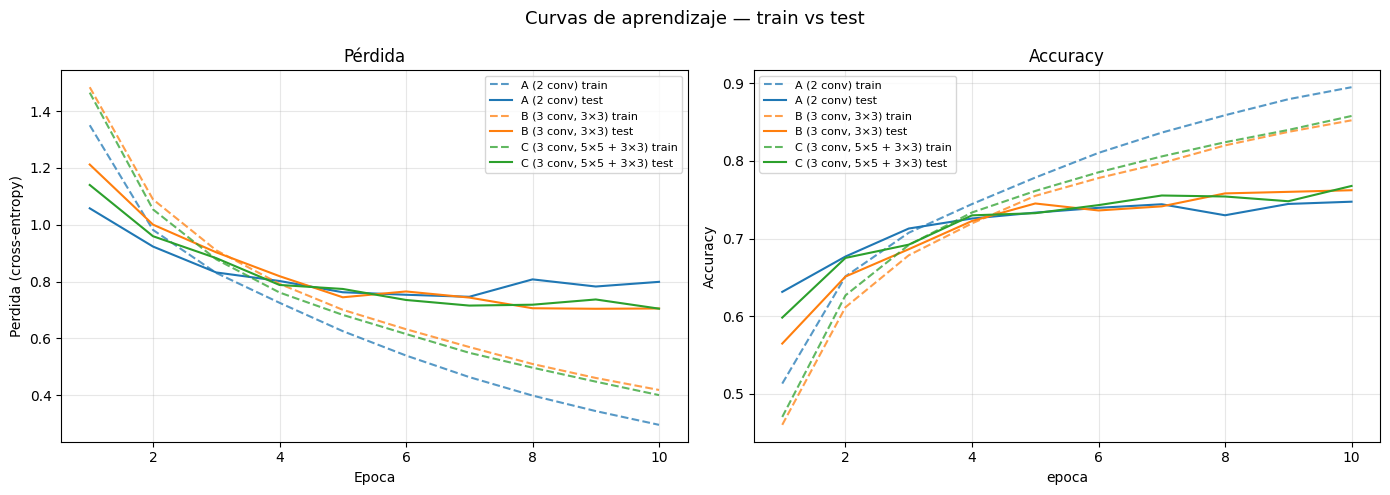


Mejor modelo (última época, test): C (3 conv, 5×5 + 3×3)
  Test accuracy: 0.7678 (76.78%)
Evaluacion completa en test: 0.7678 (76.78%)


In [4]:
EPOCHS = 10
loss_function = nn.CrossEntropyLoss()

histories = {}
for name, model in named_models.items():
    print(f"\n{'='*50}\n  {name}\n{'='*50}")
    optimizer = Adam(model.parameters())
    histories[name] = train_model(
        model,
        train_loader,
        test_loader,
        loss_function,
        optimizer,
        EPOCHS,
        device,
    )

epochs_axis = range(1, EPOCHS + 1)
colors = ["tab:blue", "tab:orange", "tab:green"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Curvas de aprendizaje — train vs test", fontsize=13)

for (name, hist), color in zip(histories.items(), colors):
    axes[0].plot(
        epochs_axis,
        hist["train_loss"],
        color=color,
        linestyle="--",
        alpha=0.75,
        label=f"{name} train",
    )
    axes[0].plot(epochs_axis, hist["test_loss"], color=color, label=f"{name} test")
    axes[1].plot(
        epochs_axis,
        hist["train_acc"],
        color=color,
        linestyle="--",
        alpha=0.75,
        label=f"{name} train",
    )
    axes[1].plot(epochs_axis, hist["test_acc"], color=color, label=f"{name} test")

axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Perdida (cross-entropy)")
axes[0].set_title("Pérdida")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("epoca")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_name = max(histories, key=lambda n: histories[n]["test_acc"][-1])
best_model = named_models[best_name]
best_acc = histories[best_name]["test_acc"][-1]
print(f"\nMejor modelo (última época, test): {best_name}")
print(f"  Test accuracy: {best_acc:.4f} ({best_acc * 100:.2f}%)")

best_model.eval()
total_correct = 0
with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        total_correct += best_model(X).argmax(dim=1).eq(y).sum().item()
final_acc = total_correct / len(test_dataset)
print(f"Evaluacion completa en test: {final_acc:.4f} ({final_acc * 100:.2f}%)")

## Reflexión

Esta actividad fue interesante ya que entrenamos y evaluamos una CNN nosotros mismos, en mi caso me resultó más util Colab ya que en mi computadora al no tener cuda como opción viable y tener que recurrir a la CPU, lo cual hacía que al momento del entrenamiento fuera bastante lento (10 a 15 minutos por cada una de las 3). Lo cual me dificultaba visualizar los cambios de manera mas rápida, por su parte al utilizar cuda en colab los tiempos se redujeron drásticamente a 3 minutos en promedio como máximo.

Finalmente aunque los hiperparámetros sean los mismo vemos como es que la arquitectura es parte fundamental al momento de querer plantear una solución, en este caso al trabajar con las CNN resulta importante para obtener los mejores resultados, sin embargo tenemos que planearla bien .